# Finding Contours

### Import resources and display image

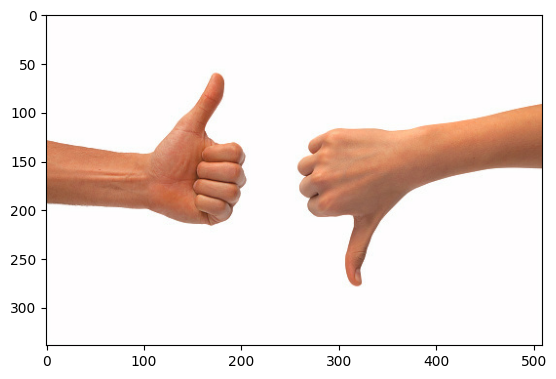

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%matplotlib inline

image = cv2.imread('images/thumbs_up_down.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)

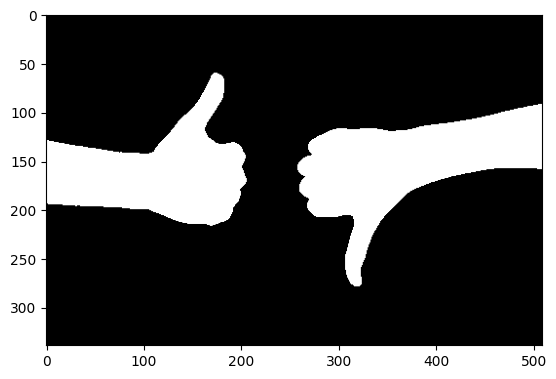

In [2]:
gray = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
retval, binary = cv2.threshold(gray, 225, 255, cv2.THRESH_BINARY_INV)

plt.imshow(binary, cmap='gray')


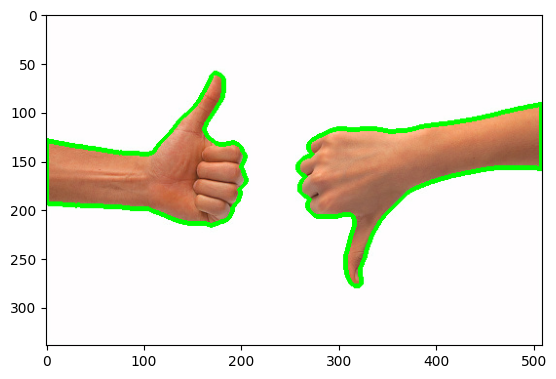

In [3]:
contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours_image = np.copy(image)
contours_image = cv2.drawContours(contours_image, contours, -1, (0,255,0), 3)

plt.imshow(contours_image)

In [4]:
def orientations(contours):
    """
    Orientation 
    :param contours: a list of contours
    :return: angles, the orientations of the contours
    """
    
    angles = []
    for contour in contours:
        (x,y), (MA,ma), angle = cv2.fitEllipse(contour)
        angles.append(angle)
    return angles


# ---------------------------------------------------------- #
angles = orientations(contours)
print('Angles of each contour (in degrees): ' + str(angles))

Angles of each contour (in degrees): [61.35833740234375, 82.27550506591797]


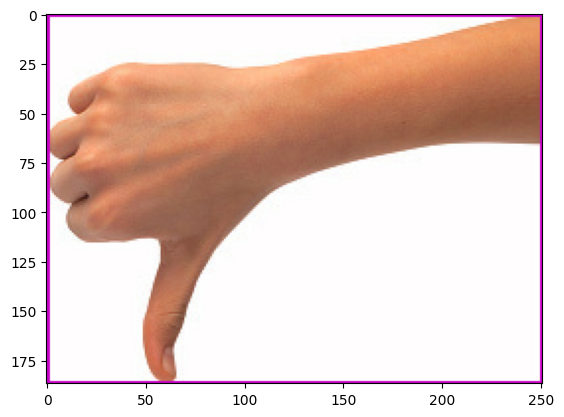

In [5]:
def left_hand_crop(image, selected_contour):
    """
    Left hand crop 
    :param image: the original image
    :param selectec_contour: the contour that will be used for cropping
    :return: cropped_image, the cropped image around the left hand
    """
    
    x,y,w,h = cv2.boundingRect(selected_contour)
    box_image = cv2.rectangle(image, (x,y), (x+w,y+h), (200,0,200),2)
    cropped_image = image[y: y + h, x: x + w] 
    return cropped_image

selected_contour = contours[0]


# ---------------------------------------------------------- #
if(selected_contour is not None):
    cropped_image = left_hand_crop(image, selected_contour)
    plt.imshow(cropped_image)